<a href="https://colab.research.google.com/github/Sia0412/Flask-Mega/blob/main/IOT_ecosystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#@title dataset shape
import pandas as pd
import numpy as np
df = pd.read_csv("/content/sample_data/digital_ecosystem_smart_healthcare_dataset.csv")
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (4000, 18)
Rows: 4000
Columns: 18


In [3]:
#@title column names
print(df.columns.tolist())

['Heart_Rate', 'Blood_Pressure', 'Blood_Oxygen_Level', 'Body_Temperature', 'Respiration_Rate', 'Glucose_Level', 'ECG_Signal_Intensity', 'Activity_Level', 'Sleep_Duration_Hours', 'Stress_Index', 'IoT_Device_Connectivity', 'EHR_Data_Completeness', 'Wearable_Device_Count', 'Daily_Steps', 'Healthcare_Network_Latency_ms', 'Cloud_Data_Transfer_Rate', 'Medical_Alert_Frequency', 'Patient_Health_Status']


In [4]:
#@title data types
df.dtypes

,0
Heart_Rate,int64
Blood_Pressure,int64
Blood_Oxygen_Level,float64
Body_Temperature,float64
Respiration_Rate,int64
Glucose_Level,int64
ECG_Signal_Intensity,float64
Activity_Level,int64
Sleep_Duration_Hours,float64
Stress_Index,int64


In [5]:
#@title missing values
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

missing_df

,Column,Missing Values
0,Heart_Rate,0
1,Blood_Pressure,0
2,Blood_Oxygen_Level,0
3,Body_Temperature,0
4,Respiration_Rate,0
5,Glucose_Level,0
6,ECG_Signal_Intensity,0
7,Activity_Level,0
8,Sleep_Duration_Hours,0
9,Stress_Index,0


In [6]:
#@title finding duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
#@title descriptive statistics
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Heart_Rate,4000.0,80.615250,27.307245,45.00,57.00000,78.000,99.00000,180.00
Blood_Pressure,4000.0,134.757000,47.428096,80.00,80.00000,131.000,184.00000,200.00
Blood_Oxygen_Level,4000.0,95.546110,4.579600,85.00,92.42750,96.740,100.00000,100.00
Body_Temperature,4000.0,36.520075,2.042645,34.00,34.74750,36.255,37.88000,41.00
Respiration_Rate,4000.0,18.101500,7.249161,8.00,12.00000,18.000,23.00000,40.00
Glucose_Level,4000.0,102.600750,41.788760,60.00,63.00000,93.000,127.00000,300.00
ECG_Signal_Intensity,4000.0,2.503020,1.437716,0.50,1.24475,2.413,3.63125,5.00
Activity_Level,4000.0,49.366750,33.483041,0.00,20.00000,50.000,77.00000,100.00
Sleep_Duration_Hours,4000.0,6.973878,2.825316,2.00,4.81750,6.980,9.08000,12.00
Stress_Index,4000.0,50.171250,34.237428,0.00,20.00000,50.000,80.00000,100.00


In [9]:
#@title target distribution
target = "Patient_Health_Status"

display(df[target].value_counts())

display(round(df[target].value_counts(normalize=True)*100,2))


,count
Patient_Health_Status,
Critical,1003
Moderate_Risk,1001
Stable,999
High_Risk,997


,proportion
Patient_Health_Status,
Critical,25.07
Moderate_Risk,25.02
Stable,24.98
High_Risk,24.92


In [10]:
#@title Feature Ranges
numeric_cols = df.select_dtypes(include=np.number).columns

ranges = pd.DataFrame({
    "Minimum": df[numeric_cols].min(),
    "Maximum": df[numeric_cols].max(),
    "Range": df[numeric_cols].max()-df[numeric_cols].min()
})

display(ranges)

,Minimum,Maximum,Range
Heart_Rate,45.00,180.00,135.00
Blood_Pressure,80.00,200.00,120.00
Blood_Oxygen_Level,85.00,100.00,15.00
Body_Temperature,34.00,41.00,7.00
Respiration_Rate,8.00,40.00,32.00
Glucose_Level,60.00,300.00,240.00
ECG_Signal_Intensity,0.50,5.00,4.50
Activity_Level,0.00,100.00,100.00
Sleep_Duration_Hours,2.00,12.00,10.00
Stress_Index,0.00,100.00,100.00


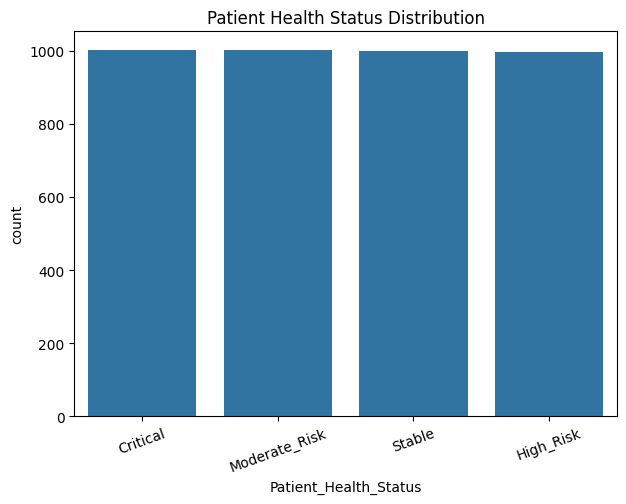

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Patient_Health_Status",
    order=df["Patient_Health_Status"].value_counts().index
)

plt.title("Patient Health Status Distribution")
plt.xticks(rotation=20)
plt.show()

In [13]:
#@title check target column (step-2)
target = "Patient_Health_Status"

if target in df.columns:
    print("Target column exists.")
else:
    print("Target column NOT found.")

Target column exists.


In [14]:
#@title class counts and percentage
print(df[target].value_counts())
print(round(df[target].value_counts(normalize=True)*100,2))

Patient_Health_Status
Critical         1003
Moderate_Risk    1001
Stable            999
High_Risk         997
Name: count, dtype: int64
Patient_Health_Status
Critical         25.07
Moderate_Risk    25.02
Stable           24.98
High_Risk        24.92
Name: proportion, dtype: float64


In [15]:
#@title Encode target labels
label_mapping = {
    "Stable": 0,
    "Moderate_Risk": 1,
    "High_Risk": 2,
    "Critical": 3
}

# Keep original labels for later interpretation
df["Patient_Health_Status_Label"] = df[target]

# Encode target
df[target] = df[target].map(label_mapping)

display(df[["Patient_Health_Status_Label",
            "Patient_Health_Status"]].head())

,Patient_Health_Status_Label,Patient_Health_Status
0,Stable,0
1,High_Risk,2
2,Stable,0
3,Moderate_Risk,1
4,Moderate_Risk,1


In [16]:
print(df[target].value_counts().sort_index())


Patient_Health_Status
0     999
1    1001
2     997
3    1003
Name: count, dtype: int64


In [17]:
#@title Prepare feature matrix and target vector
X = df.drop(columns=[
    "Patient_Health_Status",
    "Patient_Health_Status_Label"
])

y = df["Patient_Health_Status"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (4000, 17)
Target Shape: (4000,)


In [18]:
#@title step 3 (verify target column)
# Target column names

target = "Patient_Health_Status"
original_target = "Patient_Health_Status_Label"

print("Encoded Target Exists:",
      target in df.columns)

print("Original Target Exists:",
      original_target in df.columns)

Encoded Target Exists: True
Original Target Exists: True


In [19]:
print("Checking Feature Matrix...\n")

if target in X.columns:
    print("ERROR: Target column is inside X.")
else:
    print("PASS: Target column removed from X.")

if original_target in X.columns:
    print("ERROR: Original labels are inside X.")
else:
    print("PASS: Original labels removed from X.")

Checking Feature Matrix...

PASS: Target column removed from X.
PASS: Original labels removed from X.


In [21]:
#@title input feature checking
print("Input Features Used")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

Input Features Used
1. Heart_Rate
2. Blood_Pressure
3. Blood_Oxygen_Level
4. Body_Temperature
5. Respiration_Rate
6. Glucose_Level
7. ECG_Signal_Intensity
8. Activity_Level
9. Sleep_Duration_Hours
10. Stress_Index
11. IoT_Device_Connectivity
12. EHR_Data_Completeness
13. Wearable_Device_Count
14. Daily_Steps
15. Healthcare_Network_Latency_ms
16. Cloud_Data_Transfer_Rate
17. Medical_Alert_Frequency


In [22]:
#@title check for suspicions
keywords = [
    "health_status",
    "target",
    "risk",
    "label",
    "class"
]

suspected = []

for column in X.columns:

    column_lower = column.lower()

    for word in keywords:

        if word in column_lower:
            suspected.append(column)
            break

if len(suspected)==0:
    print("No suspicious feature names found.")
else:
    print("Possible leakage features:")

    for feature in suspected:
        print(feature)

No suspicious feature names found.


In [23]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

print()

if len(X)==len(y):
    print("PASS: X and y have the same number of samples.")
else:
    print("ERROR: Sample mismatch.")

Feature Matrix Shape : (4000, 17)
Target Shape : (4000,)

PASS: X and y have the same number of samples.


In [24]:
print(df[[
    "Patient_Health_Status_Label",
    "Patient_Health_Status"
]].head(10))

  Patient_Health_Status_Label  Patient_Health_Status
0                      Stable                      0
1                   High_Risk                      2
2                      Stable                      0
3               Moderate_Risk                      1
4               Moderate_Risk                      1
5                   High_Risk                      2
6                   High_Risk                      2
7                      Stable                      0
8               Moderate_Risk                      1
9                    Critical                      3


In [25]:
#@title final report to leakage
print("="*60)
print("STEP 3 COMPLETED")
print("="*60)

print("""
✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)
""")

STEP 3 COMPLETED

✓ Patient_Health_Status removed from X

✓ Original labels preserved

✓ No target-derived features created

✓ Dataset ready for Feature Engineering (Step 4)

